Ursprüngliche Anzahl Zeilen: 804
Nach Ausschluss von 'err': 804 Zeilen

Verteilung der Labels:
                                        Label  Anzahl (absolut)  Anteil (%)
                                     Economic                59    7.338308
                       Capacity and resources                 4    0.497512
                                     Morality                89   11.069652
                        Fairness and equality                12    1.492537
Legality, constitutionality and jurisprudence                82   10.199005
           Policy prescription and evaluation                28    3.482587
                         Crime and punishment                90   11.194030
                         Security and defense               154   19.154229
                            Health and safety               102   12.686567
                              Quality of life                 0    0.000000
                            Cultural identity                 6    0.

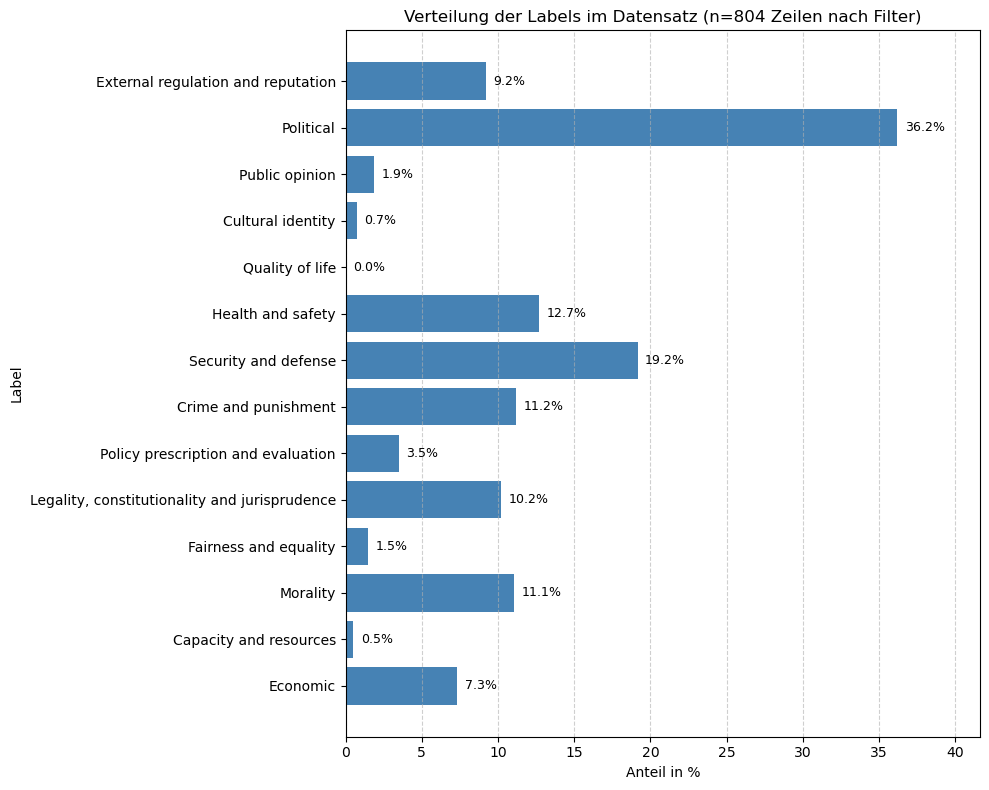

In [1]:
# -*- coding: utf-8 -*-
"""
Notebook zur Analyse der Label-Verteilung im Datensatz.
Datei: mfc_stratified_sample_converted.xlsx
Zeilen mit Headline_GER == "err" werden ausgeschlossen.
Für jede der 14 Label-Spalten wird die absolute und relative Häufigkeit berechnet.
"""

import pandas as pd
import matplotlib.pyplot as plt

# 1. Daten einlesen (angepasster Dateiname)
file_path = "ground_truth_LLM804.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# 2. Zeilen mit "err" in der Spalte "Headline_GER" ausschließen
df_clean = df[df["Headline_GER"] != "err"].copy()

print(f"Ursprüngliche Anzahl Zeilen: {len(df)}")
print(f"Nach Ausschluss von 'err': {len(df_clean)} Zeilen")

# 3. Label-Spalten definieren (Spalten C bis P)
label_columns = [
    "Economic",
    "Capacity and resources",
    "Morality",
    "Fairness and equality",
    "Legality, constitutionality and jurisprudence",
    "Policy prescription and evaluation",
    "Crime and punishment",
    "Security and defense",
    "Health and safety",
    "Quality of life",
    "Cultural identity",
    "Public opinion",
    "Political",
    "External regulation and reputation"
]

# Sicherstellen, dass alle Spalten vorhanden sind
missing = [col for col in label_columns if col not in df_clean.columns]
if missing:
    print(f"Warnung: Folgende Spalten fehlen: {missing}")
    label_columns = [col for col in label_columns if col in df_clean.columns]

# 4. Häufigkeiten berechnen
abs_counts = df_clean[label_columns].sum()
rel_counts = (abs_counts / len(df_clean)) * 100

# 5. Ergebnisse tabellarisch anzeigen
results = pd.DataFrame({
    "Label": label_columns,
    "Anzahl (absolut)": abs_counts.values,
    "Anteil (%)": rel_counts.values
})
print("\nVerteilung der Labels:")
print(results.to_string(index=False))

# 6. Visualisierung mit matplotlib (horizontaler Balkenplot)
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(label_columns, rel_counts.values, color='steelblue')

# Beschriftungen und Titel
ax.set_xlabel("Anteil in %")
ax.set_ylabel("Label")
ax.set_title(f"Verteilung der Labels im Datensatz (n={len(df_clean)} Zeilen nach Filter)")

# Werte an den Balkenenden anzeigen
for bar, value in zip(bars, rel_counts.values):
    ax.text(value + 0.5, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va='center', fontsize=9)

# Gitter für bessere Lesbarkeit
ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.set_xlim(0, max(rel_counts) * 1.15)  # etwas Platz für Text

plt.tight_layout()
plt.show()
